In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
df = pd.read_csv("borg_traces_data.csv")
df.head()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cpu_usage_distribution,tail_cpu_usage_distribution,cluster,event,failed
0,0,0,2,94591244395,3,1,200,0,144,168846390496,...,0.014435,0.000415,NaN,NaN,1.0,[0.00314331 0.00381088 0.00401306 0.00415039 0...,[0.00535583 0.00541687 0.00548553 0.00554657 0...,7,FAIL,1
1,1,2517305308183,2,260697606809,2,0,360,221495397286,335,85515092,...,0.000000,0.000000,NaN,NaN,1.0,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,[1.23977661e-05 1.23977661e-05 1.23977661e-05 ...,7,FAIL,1
2,2,195684022913,6,276227177776,2,0,103,0,376,169321752432,...,0.010422,0.000235,0.939919,0.001318,1.0,[0.01344299 0.01809692 0.0201416 0.02246094 0...,[0.02902222 0.02929688 0.0295105 0.0296936 0...,7,SCHEDULE,0
3,3,0,2,10507389885,3,0,200,0,1977,178294817221,...,0.041626,0.000225,1.359102,0.007643,1.0,[0.03704834 0.04125977 0.04290771 0.04425049 0...,[0.05535889 0.05584717 0.05633545 0.05718994 0...,8,FAIL,1
4,4,1810627494172,3,25911621841,2,0,0,0,3907,231364893292,...,0.000272,0.000010,NaN,NaN,1.0,[0. 0. 0. 0. 0...,[0.00041485 0.00041485 0.00041485 0.00041485 0...,2,FINISH,0


In [4]:
df.columns

Index(['Unnamed: 0', 'time', 'instance_events_type', 'collection_id',
       'scheduling_class', 'collection_type', 'priority',
       'alloc_collection_id', 'instance_index', 'machine_id',
       'resource_request', 'constraint', 'collections_events_type', 'user',
       'collection_name', 'collection_logical_name',
       'start_after_collection_ids', 'vertical_scaling', 'scheduler',
       'start_time', 'end_time', 'average_usage', 'maximum_usage',
       'random_sample_usage', 'assigned_memory', 'page_cache_memory',
       'cycles_per_instruction', 'memory_accesses_per_instruction',
       'sample_rate', 'cpu_usage_distribution', 'tail_cpu_usage_distribution',
       'cluster', 'event', 'failed'],
      dtype='object')

In [5]:
null_counts = df.isnull().sum()
# Print the number of null values
print(f"{null_counts.sum()} null entries have been found in the dataset\n")
# Drop null values
df.dropna(inplace=True)          # or df_df = df_df.dropna()

# Find and handle duplicates
duplicate_count = df.duplicated().sum()
# Print the number of duplicate entries
print(f"{duplicate_count} duplicate entries have been found in the dataset\n")
# Remove duplicates
df.drop_duplicates(inplace=True)  # or df_df = df_df.drop_duplicates()
# Display relative message
print(f"All duplicates have been removed\n")

# Reset the indexes
df.reset_index(drop=True, inplace=True)

# Inspect the dfset for categorical columns
print("Categorical columns:",df.select_dtypes(include=['object']).columns.tolist(),'\n')

252068 null entries have been found in the dataset

0 duplicate entries have been found in the dataset

All duplicates have been removed

Categorical columns: ['resource_request', 'constraint', 'user', 'collection_name', 'collection_logical_name', 'start_after_collection_ids', 'average_usage', 'maximum_usage', 'random_sample_usage', 'cpu_usage_distribution', 'tail_cpu_usage_distribution', 'event'] 



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280877 entries, 0 to 280876
Data columns (total 34 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Unnamed: 0                       280877 non-null  int64  
 1   time                             280877 non-null  int64  
 2   instance_events_type             280877 non-null  int64  
 3   collection_id                    280877 non-null  int64  
 4   scheduling_class                 280877 non-null  int64  
 5   collection_type                  280877 non-null  int64  
 6   priority                         280877 non-null  int64  
 7   alloc_collection_id              280877 non-null  int64  
 8   instance_index                   280877 non-null  int64  
 9   machine_id                       280877 non-null  int64  
 10  resource_request                 280877 non-null  object 
 11  constraint                       280877 non-null  object 
 12  co

In [7]:
df.describe()

,Unnamed: 0,time,instance_events_type,collection_id,scheduling_class,collection_type,priority,alloc_collection_id,instance_index,machine_id,...,scheduler,start_time,end_time,assigned_memory,page_cache_memory,cycles_per_instruction,memory_accesses_per_instruction,sample_rate,cluster,failed
count,280877.000000,2.808770e+05,280877.000000,2.808770e+05,280877.000000,280877.0,280877.000000,2.808770e+05,280877.000000,2.808770e+05,...,280877.000000,2.808770e+05,2.808770e+05,280877.000000,280877.000000,280877.000000,280877.000000,280877.000000,280877.000000,280877.000000
mean,202909.900423,3.392703e+13,2.646504,3.433718e+11,1.292783,0.0,154.888232,8.472143e+10,5892.977919,8.151840e+10,...,0.366951,1.251287e+12,1.251538e+12,0.007981,0.000428,2.185858,0.010725,0.999344,4.868117,0.271923
std,117132.257481,1.740330e+16,1.922881,2.400341e+11,0.956369,0.0,119.915897,1.796822e+11,13302.084536,1.307264e+11,...,0.481974,7.959985e+11,7.960197e+11,0.024804,0.000596,1.256613,0.007757,0.005850,2.186341,0.444951
min,2.000000,0.000000e+00,0.000000,6.824000e+03,0.000000,0.0,0.000000,0.000000e+00,0.000000,-1.000000e+00,...,0.000000,6.000000e+08,9.000000e+08,0.000000,0.000000,0.252846,0.000125,0.110000,1.000000,0.000000
25%,101425.000000,1.963540e+11,2.000000,2.021301e+11,0.000000,0.0,103.000000,0.000000e+00,552.000000,2.960862e+09,...,0.000000,5.262000e+11,5.265000e+11,0.000000,0.000011,1.067229,0.004329,1.000000,3.000000,0.000000
50%,202884.000000,1.129061e+12,2.000000,2.999502e+11,1.000000,0.0,105.000000,0.000000e+00,1672.000000,1.939971e+10,...,0.000000,1.342800e+12,1.343100e+12,0.002625,0.000249,1.918681,0.009506,1.000000,5.000000,0.000000
75%,304356.000000,1.771317e+12,5.000000,4.557591e+11,2.000000,0.0,200.000000,3.502760e+10,5174.000000,1.274050e+11,...,1.000000,1.944000e+12,1.944300e+12,0.006622,0.000541,3.156894,0.016435,1.000000,7.000000,1.000000
max,405892.000000,9.223372e+18,10.000000,8.258532e+11,3.000000,0.0,450.000000,7.426667e+11,177107.000000,8.254274e+11,...,1.000000,2.678400e+12,2.678700e+12,0.286133,0.008453,105.275932,0.084292,1.000000,8.000000,1.000000


In [8]:
df['event'].value_counts()

event
FAIL              76377
FINISH            65390
ENABLE            59134
LOST              42267
SCHEDULE          28679
EVICT              8526
KILL                410
UPDATE_PENDING       89
QUEUE                 4
UPDATE_RUNNING        1
Name: count, dtype: int64

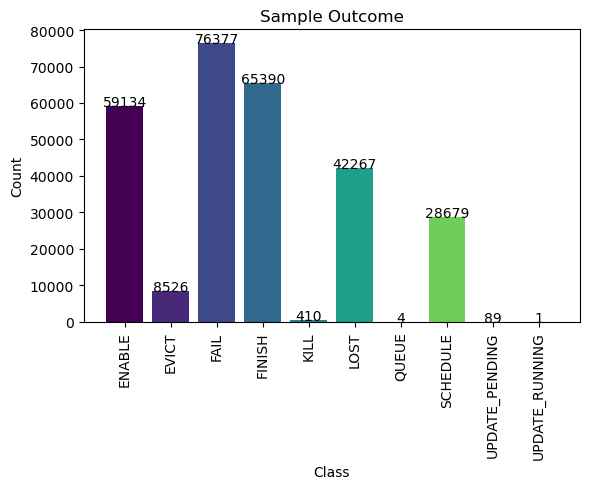

In [9]:
target = df['event'].value_counts()
labels = sorted(target.index.tolist())
sizes = target.reindex(labels).values

# Bar chart
plt.figure(figsize=(6, 5))
plt.bar(labels, sizes, color=plt.cm.viridis(np.linspace(0, 1, len(labels))))
plt.title("Sample Outcome")
plt.xlabel("Class")
plt.xticks(rotation=90)
plt.ylabel("Count")

# Show counts above bars
for i, v in enumerate(sizes):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [10]:
df['failed'].value_counts()

failed
0    204500
1     76377
Name: count, dtype: int64

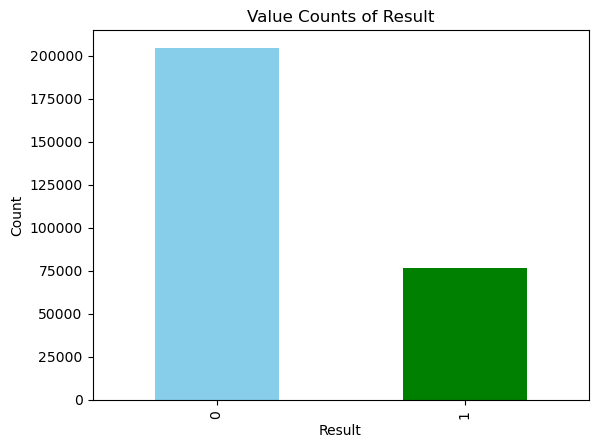

In [11]:
# Get value counts
result_counts = df['failed'].value_counts()

# Plot bar chart with multiple colors
result_counts.plot(kind='bar', color=['skyblue', 'green'])  # list colors to match count of bars
plt.xlabel('Result')
plt.ylabel('Count')
plt.title('Value Counts of Result')
plt.show()

<Axes: xlabel='cluster', ylabel='count'>

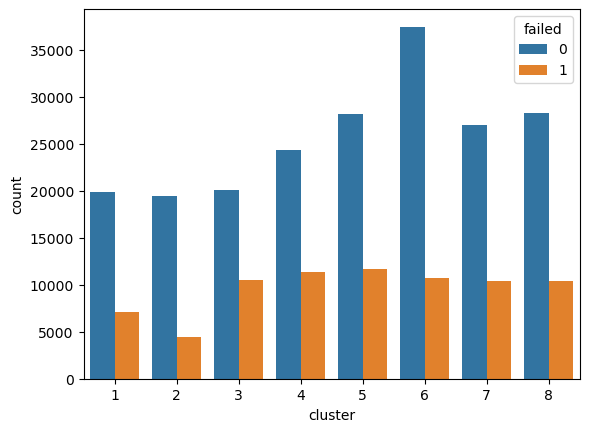

In [12]:
sns.countplot(df, x="cluster", hue="failed")

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
# Automatically find categorical columns and encode
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [14]:
def split_cell(data):
    import re
    number = re.compile(r"[0-9]")
    if type(data) != float:
        data = data.split(": ")
        cpu = data[1]
        cpu = cpu.split(",")[0]
        cpu = float(cpu)
    
        memory = data[2].split("}")
        if number.match(memory[0]):
            memory = float(memory[0])
        else:
            memory = np.nan
    else:
        cpu, memory = np.nan, np.nan
    
    return [cpu, memory]

In [15]:
dff = df.drop(['Unnamed: 0','resource_request','vertical_scaling','scheduler','cycles_per_instruction','start_after_collection_ids',
               'average_usage','maximum_usage','random_sample_usage','cpu_usage_distribution','tail_cpu_usage_distribution',
               'memory_accesses_per_instruction','resource_request','constraint'],axis=1)

In [16]:
X = dff.drop(["collection_id","machine_id", "alloc_collection_id","failed","event",'user','collection_name','collection_logical_name'], axis=1)
y = dff["failed"]

In [17]:
X

,time,instance_events_type,scheduling_class,collection_type,priority,instance_index,collections_events_type,start_time,end_time,assigned_memory,page_cache_memory,sample_rate,cluster
0,195684022913,6,2,0,103,376,6,81300000000,81600000000,0.010422,2.346039e-04,1.000000,7
1,0,2,3,0,200,1977,2,1075500000000,1075800000000,0.041626,2.250671e-04,1.000000,8
2,130721370174,0,1,0,117,13138,0,343800000000,344100000000,0.002190,5.722046e-06,1.000000,7
3,2373350421416,3,2,0,103,393,3,455400000000,455700000000,0.001474,5.912781e-05,1.000000,7
4,1970214287222,0,0,0,0,19760,0,2249100000000,2249400000000,0.006683,9.536743e-07,1.000000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
280872,407054832916,3,1,0,103,5227,3,454200000000,454500000000,0.004364,2.937317e-04,1.000000,1
280873,0,2,1,0,117,1341,2,456600000000,456900000000,0.002117,4.768372e-05,1.000000,8
280874,18279167039,0,2,0,360,898,0,943800000000,944100000000,0.000000,2.468109e-03,1.000000,1
280875,733307641549,3,3,0,200,1959,3,1161300000000,1161600000000,0.000000,4.796982e-04,1.000000,2


# Correlation Matrix

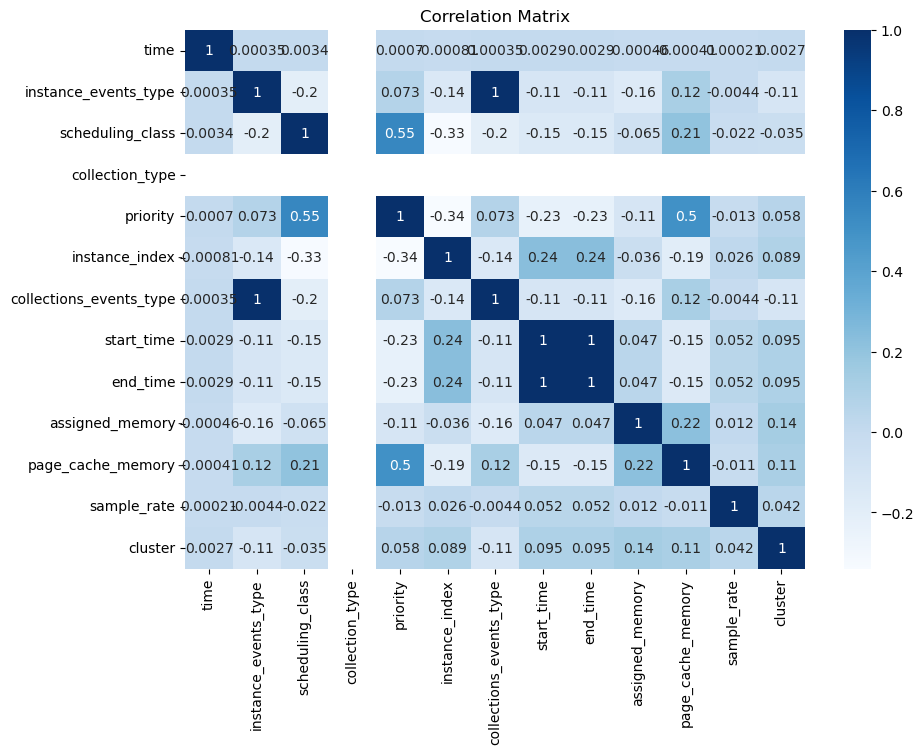

In [18]:
plt.figure(figsize = (10,7))
sns.heatmap(X.corr(), annot = True, cmap="Blues")
plt.title('Correlation Matrix')
plt.show()

# Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
x_train.shape,x_test.shape

((224701, 13), (56176, 13))

In [20]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

joblib.dump(scaler, 'Models/scaler.pkl')

['Models/scaler.pkl']

In [21]:
# import numpy as np
# z_scores = (df - np.mean(df)) / np.std(df)

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
ML_Model = []
accuracy = []
precision = []
recall = []
f1score = []

def storeResults(model, a, b, c, d):
    ML_Model.append(model)
    accuracy.append(round(a, 4))
    precision.append(round(b, 4))
    recall.append(round(c, 4))
    f1score.append(round(d, 4))

# DecisionTree

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='entropy',        
    max_depth=1,                 
    min_samples_split=20,       
    min_samples_leaf=10,        
    random_state=42
)
dt.fit(x_train, y_train)

y_pred = dt.predict(x_test)
y_prob = dt.predict_proba(x_test)[:, 1] if hasattr(dt, "predict_proba") else None

dt_acc = accuracy_score(y_test, y_pred)
dt_prec = precision_score(y_test, y_pred, average='weighted')
dt_rec = recall_score(y_test, y_pred, average='weighted')
dt_f1 = f1_score(y_test, y_pred, average='weighted')

print("Decision Tree")
print("Accuracy :", dt_acc)
print("Precision:", dt_prec)
print("Recall   :", dt_rec)
print("F1 Score :", dt_f1)

Decision Tree
Accuracy : 0.7604493021931074
Precision: 0.8722839506020356
Recall   : 0.7604493021931074
F1 Score : 0.7732736284387293


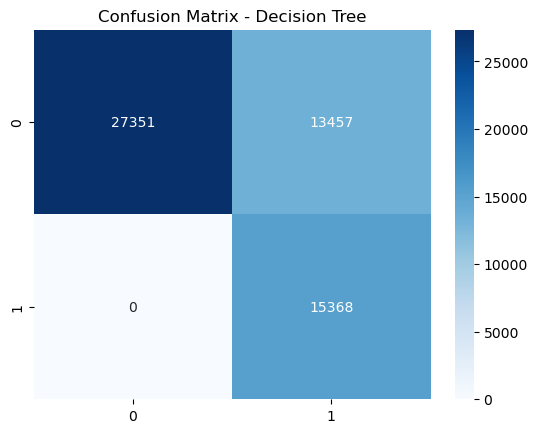

In [24]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [25]:
storeResults("Decesion Tree", dt_acc, dt_prec, dt_rec, dt_f1)

# KNN

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=10, leaf_size=1)
knn.fit(x_train, y_train)

y_pred = knn.predict(x_test)
y_prob = knn.predict_proba(x_test)[:, 1] if hasattr(dt, "predict_proba") else None

knn_acc = accuracy_score(y_test, y_pred)
knn_prec = precision_score(y_test, y_pred, average='weighted')
knn_rec = recall_score(y_test, y_pred, average='weighted')
knn_f1 = f1_score(y_test, y_pred, average='weighted')

print("KNN")
print("Accuracy :", knn_acc)
print("Precision:", knn_prec)
print("Recall   :", knn_rec)
print("F1 Score :", knn_f1)

KNN
Accuracy : 0.9993235545428653
Precision: 0.9993235008722238
Recall   : 0.9993235545428653
F1 Score : 0.9993235133678503


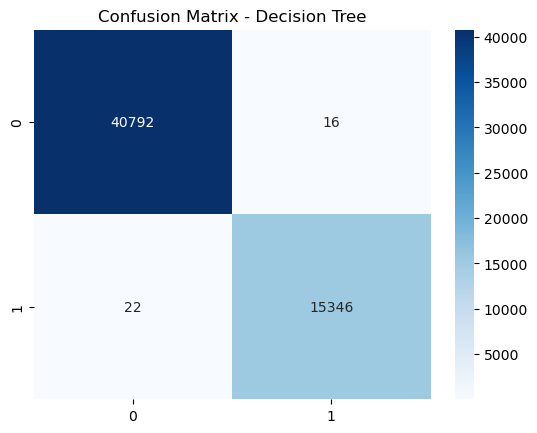

In [27]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [28]:
storeResults("KNN", knn_acc, knn_prec, knn_rec, knn_f1)

# XGBoost

In [35]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=5,           
    max_depth=1,              
    min_child_weight=20,     
    subsample=0.3,          
    colsample_bytree=0.3,     
    learning_rate=0.8,        
    gamma=5,                  
    reg_alpha=1,             
    reg_lambda=2,            
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

xgb_acc = accuracy_score(y_test, y_pred)
xgb_prec = precision_score(y_test, y_pred, average='weighted')
xgb_rec = recall_score(y_test, y_pred, average='weighted')
xgb_f1 = f1_score(y_test, y_pred, average='weighted')

print("XGBoost with")
print("Accuracy :", xgb_acc)
print("Precision:", xgb_prec)
print("Recall   :", xgb_rec)
print("F1 Score :", xgb_f1)

XGBoost with
Accuracy : 0.7687802620336086
Precision: 0.7502783296854687
Recall   : 0.7687802620336086
F1 Score : 0.7462780950300871


In [34]:
!pip install xgboost

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
storeResults("XGB", xgb_acc, xgb_prec, xgb_rec, xgb_f1)

# AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier


ada = AdaBoostClassifier(
    n_estimators=1,         
    learning_rate=1.0,      
    random_state=42
)

ada.fit(x_train, y_train)
y_pred = ada.predict(x_test)

ada_acc = accuracy_score(y_test, y_pred)
ada_prec = precision_score(y_test, y_pred, average='weighted')
ada_rec = recall_score(y_test, y_pred, average='weighted')
ada_f1 = f1_score(y_test, y_pred, average='weighted')

print("AdaBoost with Reduced Accuracy")
print("Accuracy :", ada_acc)
print("Precision:", ada_prec)
print("Recall   :", ada_rec)
print("F1 Score :", ada_f1)

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
storeResults("AdaBoost", ada_acc, ada_prec, ada_rec, ada_f1)

# ANN

In [ ]:
from sklearn.neural_network import MLPClassifier

ann = MLPClassifier(
    hidden_layer_sizes=(5,),  
    max_iter=1,             
    alpha=0.1,                
    solver='sgd',             
    random_state=42
)

ann.fit(x_train, y_train)
y_pred = ann.predict(x_test)

ann_acc = accuracy_score(y_test, y_pred)
ann_prec = precision_score(y_test, y_pred, average='weighted')
ann_rec = recall_score(y_test, y_pred, average='weighted')
ann_f1 = f1_score(y_test, y_pred, average='weighted')

print("ANN with Reduced Accuracy Settings")
print("Accuracy :", ann_acc)
print("Precision:", ann_prec)
print("Recall   :", ann_rec)
print("F1 Score :", ann_f1)

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
storeResults("ANN", ann_acc, ann_prec, ann_rec, ann_f1)

# VotingClassifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier

dt = DecisionTreeClassifier(max_depth=1, min_samples_split=20, min_samples_leaf=10)
knn = KNeighborsClassifier(n_neighbors=30, weights='uniform')
ann = MLPClassifier(hidden_layer_sizes=(5,), max_iter=100, alpha=0.1, solver='sgd', random_state=42)

vc = VotingClassifier([
    ('dt', dt),
    ('knn', knn),
    ('ann', ann)
], voting='hard')

vc.fit(x_train, y_train)
y_pred = vc.predict(x_test)

vc_acc = accuracy_score(y_test, y_pred)
vc_prec = precision_score(y_test, y_pred, average='weighted')
vc_rec = recall_score(y_test, y_pred, average='weighted')
vc_f1 = f1_score(y_test, y_pred, average='weighted')

print("Voting Classifier with Reduced Accuracy")
print("Accuracy :", vc_acc)
print("Precision:", vc_prec)
print("Recall   :", vc_rec)
print("F1 Score :", vc_f1)

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
storeResults("Voting", vc_acc, vc_prec, vc_rec, vc_f1)

# StackingClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


base_learners = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(50,), max_iter=300, random_state=42))
]


meta_learner = LogisticRegression(max_iter=300)

stacking_clf = StackingClassifier(estimators=base_learners, final_estimator=meta_learner)

stacking_clf.fit(x_train, y_train)

y_pred = stacking_clf.predict(x_test)

clf_acc = accuracy_score(y_test, y_pred)
clf_prec = precision_score(y_test, y_pred, average='weighted')
clf_rec = recall_score(y_test, y_pred, average='weighted')
clf_f1 = f1_score(y_test, y_pred, average='weighted')

print("Stacking Classifier Results")
print("Accuracy :", clf_acc)
print("Precision:", clf_prec)
print("Recall   :", clf_rec)
print("F1 Score :", clf_f1)

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

In [ ]:
storeResults("Stacking", clf_acc, clf_prec, clf_rec, clf_f1)

In [ ]:
result = pd.DataFrame({
    "ML_Model": ML_Model,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1score,
})

# Comparision Table

In [ ]:
result

# Comparison Graphs

In [ ]:
# Define a different palette for each metric
palettes = {
    'Accuracy': 'Blues',
    'Precision': 'Greens',
    'Recall': 'Purples',
    'F1 Score': 'Oranges',
}

for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    plt.figure(figsize=(8, 6))
    sns.barplot(data=result, x='ML_Model', y=metric, palette=palettes[metric])
    plt.title(f'{metric} by Model')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Model Saving

In [ ]:
import joblib
filename = 'Models/stacking_clf.sav'
joblib.dump(stacking_clf, filename)

# XAI

In [ ]:
model = joblib.load('Models/stacking_clf.sav')

# XAI-LIME

In [ ]:
import shap
from lime.lime_tabular import LimeTabularExplainer


feature_names = X.columns.tolist()

# Initialize LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=x_train,
    feature_names=feature_names,
    class_names=['No','Yes'],
    mode='classification'
)

# Explain first instance
i = 0
lime_exp = lime_explainer.explain_instance(
    data_row=x_test[i],
    predict_fn=model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook() 

In [ ]:
import plotly.graph_objects as go

label_idx = lime_exp.available_labels()[0]
exp_list = lime_exp.as_list(label=label_idx)
features, weights = zip(*exp_list)

fig = go.Figure(go.Waterfall(
    name="LIME Explanation",
    orientation="v",
    measure=["relative"] * len(weights),
    x=features,
    text=[f"{w:.2f}" for w in weights],
    y=weights,
))

fig.update_layout(title=f"LIME Waterfall Explanation (Label: {label_idx})")
fig.show()

# XAI-SHAP

In [ ]:
import shap

X_train_np = x_train if isinstance(x_train, np.ndarray) else x_train.to_numpy()
X_test_np = x_test if isinstance(x_test, np.ndarray) else x_test.to_numpy()

feature_names = X.columns.tolist()
X_train_df = pd.DataFrame(X_train_np)  

X_background = X_train_df.sample(10, random_state=42)
X_explain = X_train_df.sample(100, random_state=1)

explainer = shap.KernelExplainer(model.predict_proba, X_background)
shap_values = explainer.shap_values(X_explain, nsamples=100)

shap_class_1 = shap_values[:, :, 1]

print("SHAP shape:", shap_class_1.shape)
shap.summary_plot(shap_class_1, X_explain, feature_names=feature_names)

In [ ]:
shap.initjs()
shap.plots.force(
    explainer.expected_value[1],
    shap_values[0, :, 1],
    x_test.iloc[0]
)